<a href="https://colab.research.google.com/github/jadhavsiya481-hash/Python-Basic-Projects/blob/main/Assignment_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [7]:
#1
import pandas as pd
df = pd.read_csv("heart.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
#2
print("Missing Values in the dataset")
df.isnull().sum()

Missing Values in the dataset


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [20]:
#3
duplicates = df.duplicated().sum()
print(f"Duplicate rows:{duplicates}")
df = df.drop_duplicates()


Duplicate rows:0


In [23]:
#4
cholesterol_zero = (df['Cholesterol'] == 0).sum()
print(f"Number of rows with Cholesterol = 0: {cholesterol_zero}")

bp_zero = (df['RestingBP'] == 0).sum()
print(f"Number of rows with RestingBP = 0: {bp_zero}")

Number of rows with Cholesterol = 0: 172
Number of rows with RestingBP = 0: 1


In [26]:
#5
print(df[['Cholesterol','RestingBP']].describe())
df['Cholesterol'] = df['Cholesterol'].replace(0,df['Cholesterol'].mean())
df['RestingBP'] = df['RestingBP'].replace(0,df['RestingBP'].mean())

df['Cholesterol']=df['Cholesterol'].round(2)
df['RestingBP']=df['RestingBP'].round(2)

print(df[["Cholesterol","RestingBP"]].describe())

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    236.047495  132.540741
std      56.240898   17.989932
min      85.000000   80.000000
25%     198.800000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


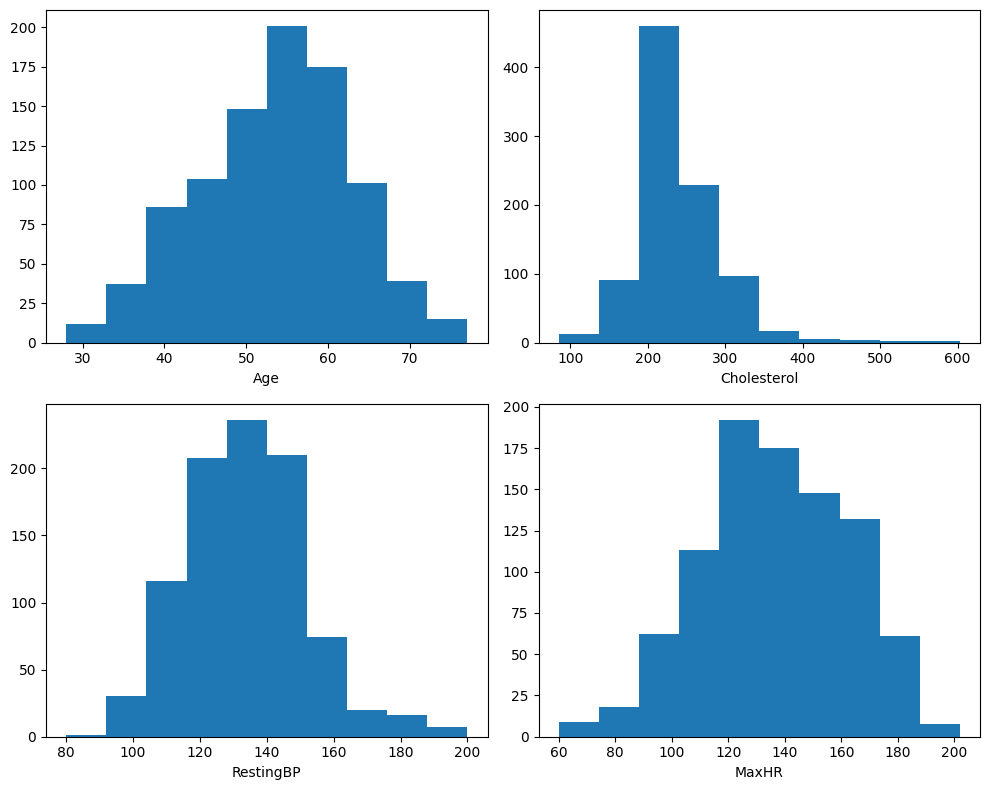

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.hist(df['Age'])
plt.xlabel('Age')

plt.subplot(2,2,2)
plt.hist(df['Cholesterol'])
plt.xlabel('Cholesterol')

plt.subplot(2,2,3)
plt.hist(df['RestingBP'])
plt.xlabel('RestingBP')

plt.subplot(2,2,4)
plt.hist(df['MaxHR'])
plt.xlabel('MaxHR')

plt.tight_layout()
plt.show()


In [31]:
#7
numerical = df.select_dtypes(include='number').columns
categorical = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(numerical)
print("Categorical Columns:")
print(categorical)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')
Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [37]:
df_encoded = pd.get_dummies(df)
print("Shape:",df_encoded.shape)
df_encoded.head()

Shape: (918, 21)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [40]:
print("Final Shape:",df_encoded.shape)
print("Column Names:",df_encoded.columns.tolist())


Final Shape: (918, 21)
Column Names: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [41]:
#10
#Q.1. What invalid values did I find and how did I fix them?
#    - There were no invalid values found in the dataset. Cholesterol=0 and RestingBP=0.

#Q.2. Why is it important to handle invalid values like Cholesterol = 0?
#    - It is important to handle invalid values so that the countinuity of the dataset is
#      maintained, and we achieve that by replacing the invalid values with the mean of the resp columns.

#Q.3. What is the purpose of one-hot encoding?
#    - One-Hot encoding converts categorical data into numerical form so machine learning algorithms can use it.

#Q.4. Any other observations from the cleaning process.
#    - 1. No missing values were found after checking.
#      2. Records in which the cholesterol data was invalid, it was replaced with the mean cholesterol value.
#         Same was practiced for RestingBP.
#      3. The concept of One-Hot Encoding was used.
#      4. Both the cholesterol and RestingBP columns were rounded upto 2 decimal places after cleaning.